In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# To display plots nicely
%matplotlib inline

In [ ]:
df = pd.read_csv("cardioclean.csv")

df.head()

,patient_id,age,gender,chest_pain_type,resting_bp,serum_chol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,major_vessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
df.shape

(1000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   int64  
 3   chest_pain_type      1000 non-null   int64  
 4   resting_bp           1000 non-null   int64  
 5   serum_chol           1000 non-null   int64  
 6   fasting_blood_sugar  1000 non-null   int64  
 7   resting_ecg          1000 non-null   int64  
 8   max_heart_rate       1000 non-null   int64  
 9   exercise_angina      1000 non-null   int64  
 10  oldpeak              1000 non-null   float64
 11  slope                1000 non-null   int64  
 12  major_vessels        1000 non-null   int64  
 13  target               1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
chest_pain_type,0
resting_bp,0
serum_chol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0


In [ ]:
df.describe()

,patient_id,age,gender,chest_pain_type,resting_bp,serum_chol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,major_vessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [ ]:
df['target'].value_counts()

,count
target,
1,580
0,420


In [ ]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
1,58.0
0,42.0


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
X.shape
y.shape

(1000,)

In [ ]:
X = df.drop(['target', 'patient_id'], axis=1)
y = df['target']

In [ ]:
X.shape

(1000, 12)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(800, 12)
(200, 12)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.965


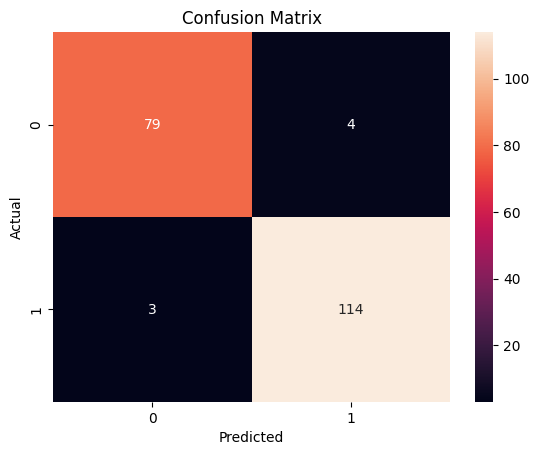

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.965
Precision: 0.9661016949152542
Recall: 0.9743589743589743
F1 Score: 0.9702127659574468


                Feature  Importance
10                slope    4.711599
1                gender    1.996346
2       chest_pain_type    0.913998
6           resting_ecg    0.790702
9               oldpeak    0.768520
5   fasting_blood_sugar    0.605781
11        major_vessels    0.297105
8       exercise_angina    0.090245
3            resting_bp    0.029915
7        max_heart_rate    0.010555
4            serum_chol    0.001820
0                   age    0.000109


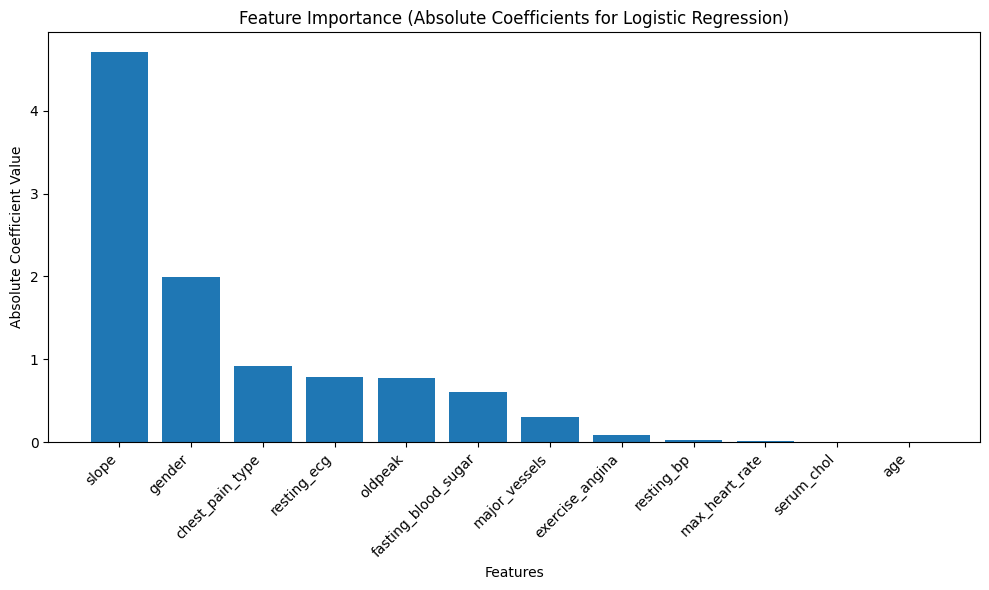

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for absolute value

# Get feature importance from coefficients
# For binary classification, model.coef_ returns a 2D array, so we take the first row.
importance = np.abs(model.coef_[0])

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Print importance
print(feature_importance)

# Plot graph
plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance (Absolute Coefficients for Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Absolute Coefficient Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Add predictions column to dataset
df['Predicted_Risk'] = model.predict(X)

# See data
df.head()

,patient_id,age,gender,chest_pain_type,resting_bp,serum_chol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,major_vessels,target,Predicted_Risk
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1,1


In [ ]:
df.to_csv('Healthcare_Risk_Predictions_Final.csv', index=False)